In [1]:
!pip -q install scikit-learn

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Keeping the seed fixed so I get the same result when I run this again
def set_random_seed(seed_value=21):
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)

set_random_seed(21)

In [3]:
# Creating a nonlinear regression dataset with 3 input variables
def create_regression_data(sample_count=6200, noise_level=0.07, seed_value=21):
    rng = np.random.default_rng(seed_value)

    input_1 = rng.uniform(-2.8, 2.8, size=(sample_count, 1))
    input_2 = rng.uniform(-2.6, 2.6, size=(sample_count, 1))
    input_3 = rng.uniform(-2.4, 2.4, size=(sample_count, 1))

    # Slightly changing the equation so this notebook is not exactly the same
    target = (
        np.sin(1.12 * input_1)
        + 0.44 * (input_2 ** 2)
        - 0.58 * np.cos(1.7 * input_3)
        + 0.23 * (input_1 * input_2)
        - 0.17 * (input_2 * input_3)
        + 0.09 * (input_1 ** 2)
    )

    # Adding a bit of noise so the regression problem is not too perfect
    target = target + rng.normal(0.0, noise_level, size=target.shape)

    features = np.concatenate([input_1, input_2, input_3], axis=1).astype(np.float32)
    target = target.astype(np.float32)

    return features, target

X_data, y_data = create_regression_data()

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=21
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4960, 3)
y_train shape: (4960, 1)
X_test shape: (1240, 3)
y_test shape: (1240, 1)


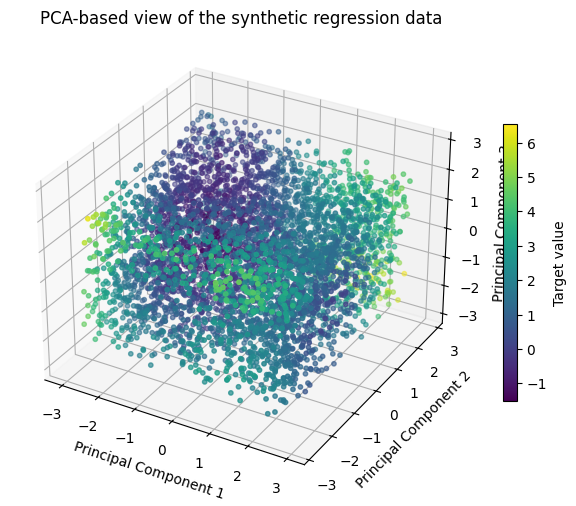

In [4]:
# A true 4D plot is not easy to show clearly, so I used PCA here
# and then used color to represent the target values
pca_model = PCA(n_components=3, random_state=21)
X_train_pca = pca_model.fit_transform(X_train)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

scatter_plot = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=y_train.squeeze(),
    s=10
)

ax.set_title("PCA-based view of the synthetic regression data")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.colorbar(scatter_plot, ax=ax, shrink=0.6, label="Target value")
plt.show()

In [5]:
# -------------------------------
# TensorFlow low-level version
# -------------------------------

input_dim, hidden_dim_1, hidden_dim_2, output_dim = 3, 56, 28, 1

weights_1 = tf.Variable(
    tf.random.normal([input_dim, hidden_dim_1]) * tf.sqrt(2.0 / tf.cast(input_dim, tf.float32))
)
bias_1 = tf.Variable(tf.zeros([hidden_dim_1]))

weights_2 = tf.Variable(
    tf.random.normal([hidden_dim_1, hidden_dim_2]) * tf.sqrt(2.0 / tf.cast(hidden_dim_1, tf.float32))
)
bias_2 = tf.Variable(tf.zeros([hidden_dim_2]))

weights_3 = tf.Variable(tf.random.normal([hidden_dim_2, output_dim]) * 0.05)
bias_3 = tf.Variable(tf.zeros([output_dim]))

# This version does the forward pass manually without high-level Keras layers
def forward_low_level(input_tensor):
    z_1 = tf.einsum("ni,io->no", input_tensor, weights_1) + bias_1
    a_1 = tf.tanh(z_1)

    z_2 = tf.einsum("ni,io->no", a_1, weights_2) + bias_2
    a_2 = tf.tanh(z_2)

    predicted_output = tf.einsum("ni,io->no", a_2, weights_3) + bias_3
    return predicted_output

In [6]:
optimizer_low_level = tf.keras.optimizers.Adam(learning_rate=0.001)

X_train_tf = tf.convert_to_tensor(X_train)
y_train_tf = tf.convert_to_tensor(y_train)
X_test_tf = tf.convert_to_tensor(X_test)
y_test_tf = tf.convert_to_tensor(y_test)

@tf.function
def train_step_low_level(X_batch, y_batch):
    with tf.GradientTape() as tape:
        predicted_output = forward_low_level(X_batch)
        loss_value = tf.reduce_mean((predicted_output - y_batch) ** 2)

    gradients = tape.gradient(
        loss_value, [weights_1, bias_1, weights_2, bias_2, weights_3, bias_3]
    )
    optimizer_low_level.apply_gradients(
        zip(gradients, [weights_1, bias_1, weights_2, bias_2, weights_3, bias_3])
    )
    return loss_value

epochs = 180
batch_size = 256

train_loss_low_level = []
test_loss_low_level = []

sample_count = X_train.shape[0]

for epoch in range(1, epochs + 1):
    shuffled_indices = np.random.permutation(sample_count)

    for start_idx in range(0, sample_count, batch_size):
        batch_indices = shuffled_indices[start_idx:start_idx + batch_size]
        batch_loss = train_step_low_level(
            tf.gather(X_train_tf, batch_indices),
            tf.gather(y_train_tf, batch_indices)
        )

    # Checking train and test loss after each epoch
    train_predictions_ll = forward_low_level(X_train_tf)
    test_predictions_ll = forward_low_level(X_test_tf)

    current_train_loss = tf.reduce_mean((train_predictions_ll - y_train_tf) ** 2).numpy()
    current_test_loss = tf.reduce_mean((test_predictions_ll - y_test_tf) ** 2).numpy()

    train_loss_low_level.append(current_train_loss)
    test_loss_low_level.append(current_test_loss)

    if epoch == 1 or epoch % 25 == 0:
        print(f"Epoch {epoch:3d} | Train MSE: {current_train_loss:.6f} | Test MSE: {current_test_loss:.6f}")

Epoch   1 | Train MSE: 3.321046 | Test MSE: 2.964498
Epoch  25 | Train MSE: 0.295512 | Test MSE: 0.280806
Epoch  50 | Train MSE: 0.037610 | Test MSE: 0.034044
Epoch  75 | Train MSE: 0.017159 | Test MSE: 0.016379
Epoch 100 | Train MSE: 0.010122 | Test MSE: 0.009853
Epoch 125 | Train MSE: 0.008786 | Test MSE: 0.008775
Epoch 150 | Train MSE: 0.007213 | Test MSE: 0.007165
Epoch 175 | Train MSE: 0.006611 | Test MSE: 0.006659


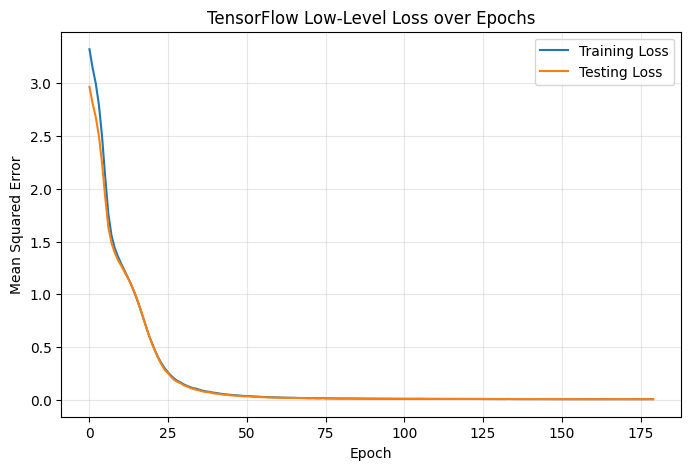

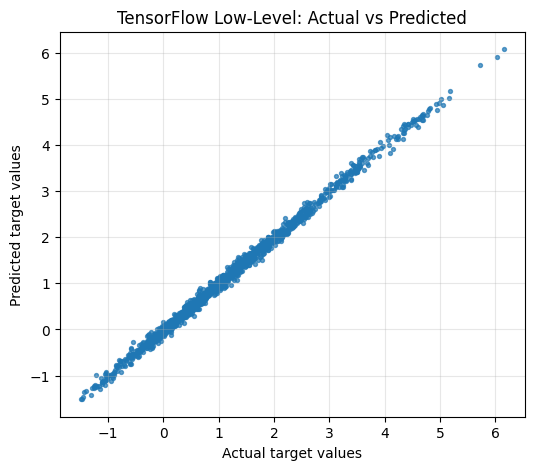

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_low_level, label="Training Loss")
plt.plot(test_loss_low_level, label="Testing Loss")
plt.title("TensorFlow Low-Level Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

yhat_test_low_level = forward_low_level(X_test_tf).numpy()

plt.figure(figsize=(6, 5))
plt.scatter(y_test.squeeze(), yhat_test_low_level.squeeze(), s=8, alpha=0.7)
plt.xlabel("Actual target values")
plt.ylabel("Predicted target values")
plt.title("TensorFlow Low-Level: Actual vs Predicted")
plt.grid(alpha=0.3)
plt.show()

In [8]:
# -------------------------------
# TensorFlow Sequential version
# -------------------------------

model_sequential = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(56, activation="tanh"),
    tf.keras.layers.Dense(28, activation="tanh"),
    tf.keras.layers.Dense(1)
])

model_sequential.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

history_sequential = model_sequential.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=180,
    batch_size=256,
    verbose=0
)

print("Sequential final validation loss:", history_sequential.history["val_loss"][-1])

Sequential final validation loss: 0.009025863371789455


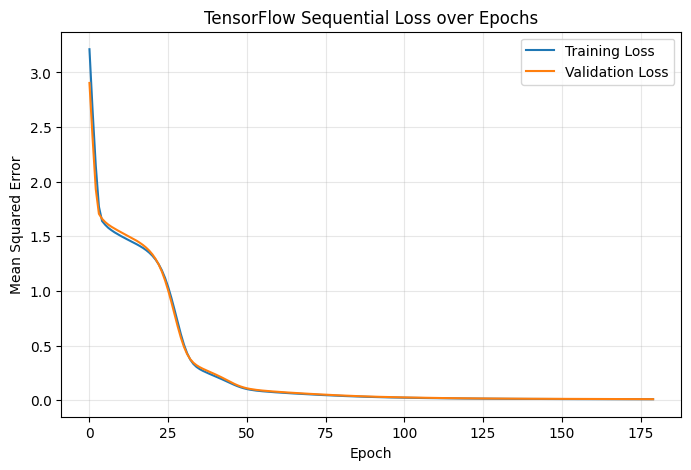

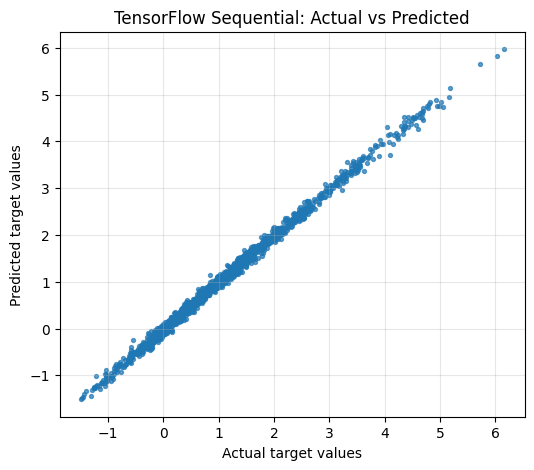

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history_sequential.history["loss"], label="Training Loss")
plt.plot(history_sequential.history["val_loss"], label="Validation Loss")
plt.title("TensorFlow Sequential Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

yhat_test_sequential = model_sequential.predict(X_test, verbose=0)

plt.figure(figsize=(6, 5))
plt.scatter(y_test.squeeze(), yhat_test_sequential.squeeze(), s=8, alpha=0.7)
plt.xlabel("Actual target values")
plt.ylabel("Predicted target values")
plt.title("TensorFlow Sequential: Actual vs Predicted")
plt.grid(alpha=0.3)
plt.show()

In [10]:
# -------------------------------
# TensorFlow Functional API version
# -------------------------------

input_layer = tf.keras.Input(shape=(3,))
hidden_layer_1 = tf.keras.layers.Dense(56, activation="tanh")(input_layer)
hidden_layer_2 = tf.keras.layers.Dense(28, activation="tanh")(hidden_layer_1)
output_layer = tf.keras.layers.Dense(1)(hidden_layer_2)

model_functional = tf.keras.Model(inputs=input_layer, outputs=output_layer)

model_functional.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

history_functional = model_functional.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=180,
    batch_size=256,
    verbose=0
)

print("Functional API final validation loss:", history_functional.history["val_loss"][-1])

Functional API final validation loss: 0.011669156141579151


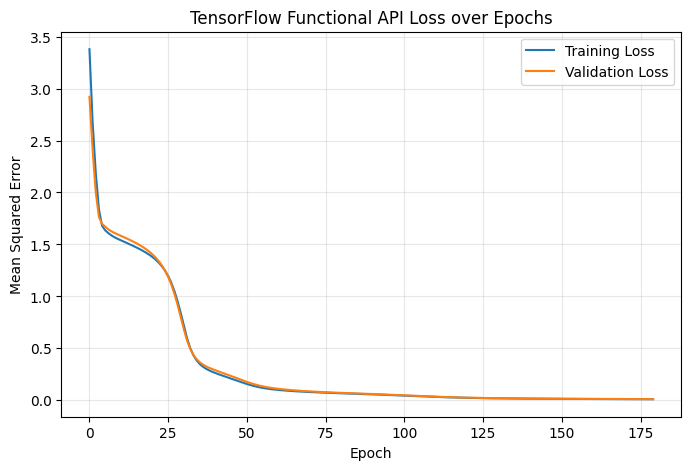

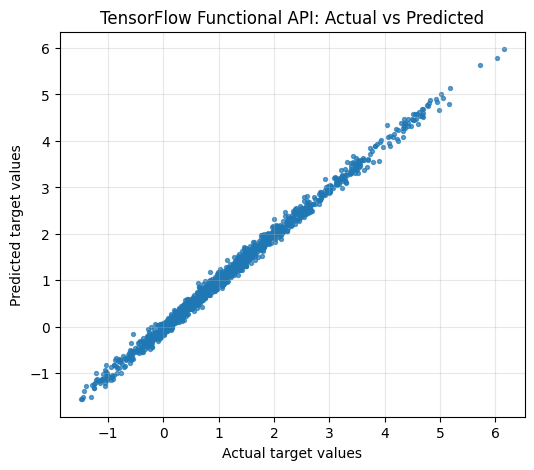

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history_functional.history["loss"], label="Training Loss")
plt.plot(history_functional.history["val_loss"], label="Validation Loss")
plt.title("TensorFlow Functional API Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

yhat_test_functional = model_functional.predict(X_test, verbose=0)

plt.figure(figsize=(6, 5))
plt.scatter(y_test.squeeze(), yhat_test_functional.squeeze(), s=8, alpha=0.7)
plt.xlabel("Actual target values")
plt.ylabel("Predicted target values")
plt.title("TensorFlow Functional API: Actual vs Predicted")
plt.grid(alpha=0.3)
plt.show()

In [12]:
# -------------------------------
# TensorFlow subclassed model version
# -------------------------------

class CustomRegressionModel(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.hidden_layer_1 = tf.keras.layers.Dense(56, activation="tanh")
        self.hidden_layer_2 = tf.keras.layers.Dense(28, activation="tanh")
        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, inputs):
        x = self.hidden_layer_1(inputs)
        x = self.hidden_layer_2(x)
        return self.output_layer(x)

model_subclassed = CustomRegressionModel()

model_subclassed.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

history_subclassed = model_subclassed.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=180,
    batch_size=256,
    verbose=0
)

print("Subclassed model final validation loss:", history_subclassed.history["val_loss"][-1])

Subclassed model final validation loss: 0.011845618486404419


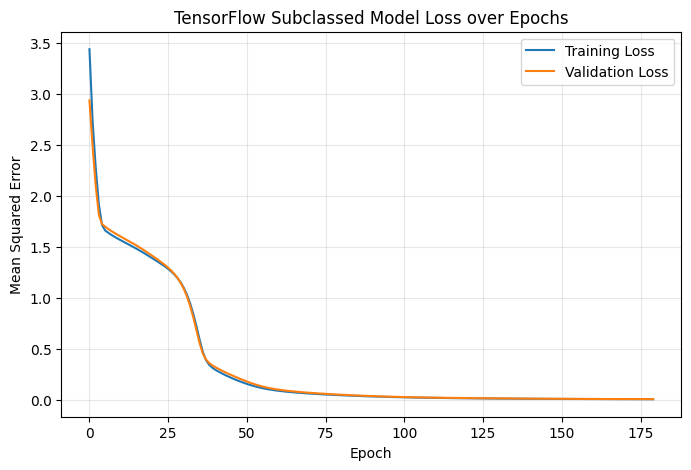

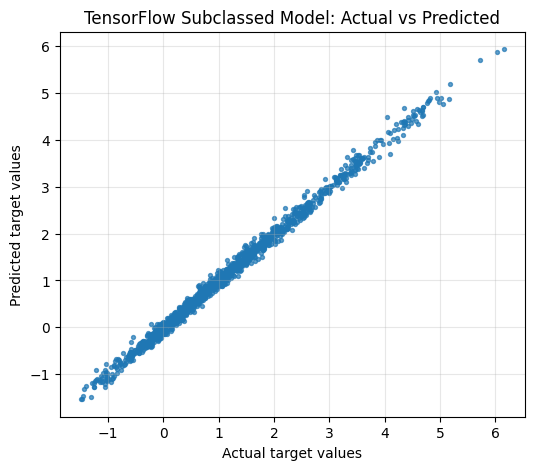

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history_subclassed.history["loss"], label="Training Loss")
plt.plot(history_subclassed.history["val_loss"], label="Validation Loss")
plt.title("TensorFlow Subclassed Model Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

yhat_test_subclassed = model_subclassed.predict(X_test, verbose=0)

plt.figure(figsize=(6, 5))
plt.scatter(y_test.squeeze(), yhat_test_subclassed.squeeze(), s=8, alpha=0.7)
plt.xlabel("Actual target values")
plt.ylabel("Predicted target values")
plt.title("TensorFlow Subclassed Model: Actual vs Predicted")
plt.grid(alpha=0.3)
plt.show()

In [14]:
# Just comparing the final test metrics for all TensorFlow versions
def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def calculate_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

results_summary = {
    "Low-Level TF": (
        calculate_mse(y_test, yhat_test_low_level),
        calculate_mae(y_test, yhat_test_low_level)
    ),
    "Sequential": (
        calculate_mse(y_test, yhat_test_sequential),
        calculate_mae(y_test, yhat_test_sequential)
    ),
    "Functional API": (
        calculate_mse(y_test, yhat_test_functional),
        calculate_mae(y_test, yhat_test_functional)
    ),
    "Subclassed Model": (
        calculate_mse(y_test, yhat_test_subclassed),
        calculate_mae(y_test, yhat_test_subclassed)
    )
}

for model_name, (mse_value, mae_value) in results_summary.items():
    print(f"{model_name:18s} | Test MSE: {mse_value:.6f} | Test MAE: {mae_value:.6f}")

Low-Level TF       | Test MSE: 0.007244 | Test MAE: 0.067274
Sequential         | Test MSE: 0.007773 | Test MAE: 0.069448
Functional API     | Test MSE: 0.010065 | Test MAE: 0.079471
Subclassed Model   | Test MSE: 0.010658 | Test MAE: 0.081289


### Final Observation
In this notebook, I implemented the same nonlinear regression problem using multiple TensorFlow styles: a low-level version, a Sequential model, a Functional API model, and a subclassed model. All of them were able to learn the overall pattern in the data, but the higher-level TensorFlow versions made the code shorter and easier to manage compared to the low-level implementation.